# Assignment 2: ML Model Training & Evaluation

In [54]:
%load_ext cuml.accel
# For gpu accelaration

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [55]:

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib import request
import io
import gc
from datetime import datetime

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

fixed_seed = 42             # Fixed seed of 42 specified
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Using device:", device)

PyTorch version: 2.10.0+cu128
Using device: cuda


# Part 1: Data Preprocessing & Feature Engineering

In this part, we:

1. Load the cleaned taxi dataset and taxi zone lookup table  
2. Filter to **credit card trips only**  
3. Create the required engineered features  
4. Create the regression and classification targets  
5. Split the data into train/validation/test sets  
6. Fit preprocessing on the training set only

## Feature Engineering and Target Variable Creation

#### Some code is taken from assignment 1 to recreate the cleaned dataset and then coupled with other requirements.

In [56]:
def load_data():

    parq_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
    lut_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

    with request.urlopen(parq_url) as parq_file:
        parquet_bytes = parq_file.read()

    df = pd.read_parquet(io.BytesIO(parquet_bytes))

    with request.urlopen(lut_url) as lut_file:
        lut_bytes = lut_file.read()

    lut = pd.read_csv(io.BytesIO(lut_bytes))

    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")

    required_columns = [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "PULocationID",
        "DOLocationID",
        "passenger_count",
        "trip_distance",
        "fare_amount",
        "tip_amount",
        "total_amount",
        "payment_type"
    ]

    df = df.dropna(subset=required_columns).copy()

    df = df[
        (df["trip_distance"] > 0.0) &
        (df["fare_amount"] > 0.0) &
        (df["total_amount"] > 0.0) &
        (df["total_amount"] <= 500)
    ].copy()

    df = df[
        (df["tpep_pickup_datetime"] < df["tpep_dropoff_datetime"]) &
        (df["tpep_pickup_datetime"] >= datetime(2024, 1, 1)) &
        (df["tpep_pickup_datetime"] < datetime(2024, 2, 1))
    ].copy()


    df = df[df["payment_type"] == 1].copy()


    # a)
    df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
    df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek
    df["is_weekend"] = df["pickup_day_of_week"].isin([5, 6]).astype(int)

    # b)
    df["trip_duration_minutes"] = (
        (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60.0
    )

    df["trip_speed_mph"] = np.where(
        df["trip_duration_minutes"] > 0,
        df["trip_distance"] / (df["trip_duration_minutes"] / 60.0),
        0
    )

    df["log_trip_distance"] = np.log1p(df["trip_distance"])

    # c)
    df["fare_per_mile"] = np.where(
        df["trip_distance"] > 0,
        df["fare_amount"] / df["trip_distance"],
        0
    )

    df["fare_per_minute"] = np.where(
        df["trip_duration_minutes"] > 0,
        df["fare_amount"] / df["trip_duration_minutes"],
        0
    )

    # For d)
    pickup_lut = lut[["LocationID", "Borough"]].rename(columns={
        "LocationID": "PULocationID",
        "Borough": "pickup_borough"
    })

    dropoff_lut = lut[["LocationID", "Borough"]].rename(columns={
        "LocationID": "DOLocationID",
        "Borough": "dropoff_borough"
    })

    df = df.merge(pickup_lut, on="PULocationID", how="left")
    df = df.merge(dropoff_lut, on="DOLocationID", how="left")

    df["pickup_borough"] = df["pickup_borough"].fillna("Unknown")
    df["dropoff_borough"] = df["dropoff_borough"].fillna("Unknown")

    # 2) a and b
    df["target_tip_amount"] = df["tip_amount"]

    df["high_tip"] = (
        df["tip_amount"] > 0.20 * df["fare_amount"]
    ).astype(int)

    df = df.reset_index(drop=True)

    return df

df = load_data()

print(df.head())

   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2024-01-01 00:03:00   2024-01-01 00:09:36              1.0   
1         1  2024-01-01 00:17:06   2024-01-01 00:35:01              1.0   
2         1  2024-01-01 00:36:38   2024-01-01 00:44:56              1.0   
3         1  2024-01-01 00:46:51   2024-01-01 00:52:57              1.0   
4         1  2024-01-01 00:54:08   2024-01-01 01:26:31              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0            1.8         1.0                  N           140           236   
1            4.7         1.0                  N           236            79   
2            1.4         1.0                  N            79           211   
3            0.8         1.0                  N           211           148   
4            4.7         1.0                  N           148           141   

   payment_type  ...  is_weekend  trip_duration_minutes  trip_speed_mph  \

## Print for debugging

In [57]:
print(df[["fare_amount", "tip_amount", "target_tip_amount", "high_tip"]].head())

print("\nHigh-tip distribution:")
print(df["high_tip"].value_counts(normalize=True))

   fare_amount  tip_amount  target_tip_amount  high_tip
0         10.0        3.75               3.75         1
1         23.3        3.00               3.00         0
2         10.0        2.00               2.00         0
3          7.9        3.20               3.20         1
4         29.6        6.90               6.90         1

High-tip distribution:
high_tip
1    0.759326
0    0.240674
Name: proportion, dtype: float64


### We split the data into categorical and numerical.

In [58]:
feature_columns = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "pickup_hour",
    "pickup_day_of_week",
    "is_weekend",
    "trip_duration_minutes",
    "trip_speed_mph",
    "log_trip_distance",
    "fare_per_mile",
    "fare_per_minute",
    "pickup_borough",
    "dropoff_borough"
]

X = df[feature_columns].copy()
y_reg = df["target_tip_amount"].copy()
y_clf = df["high_tip"].copy()

# Separating the data into categorical and numerical data and building preprocessing pipeline
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_temp, y_reg_train, y_reg_temp, y_clf_train, y_clf_temp = train_test_split(
    X, y_reg, y_clf,
    test_size=0.30,
    random_state=42,
    stratify=y_clf
)

X_val, X_test, y_reg_val, y_reg_test, y_clf_val, y_clf_test = train_test_split(
    X_temp, y_reg_temp, y_clf_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_clf_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)



Numeric features: ['passenger_count', 'trip_distance', 'fare_amount', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
Categorical features: ['pickup_borough', 'dropoff_borough']
Train shape: (1608834, 13)
Validation shape: (344750, 13)
Test shape: (344751, 13)


### Fitting on training data only

In [59]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

Processed training shape: (1608834, 23)
Processed validation shape: (344750, 23)
Processed test shape: (344751, 23)


### Finding the number of samples in each split and the class distribution of high_tip in each split.

In [60]:
def show_class_distribution(y, name):
    print(f"\n{name}")
    print(y.value_counts())
    print(y.value_counts(normalize=True))

show_class_distribution(y_clf_train, "Training set high_tip distribution")
show_class_distribution(y_clf_val, "Validation set high_tip distribution")
show_class_distribution(y_clf_test, "Test set high_tip distribution")

encoded_category_names = preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_category_names)


Training set high_tip distribution
high_tip
1    1221630
0     387204
Name: count, dtype: int64
high_tip
1    0.759326
0    0.240674
Name: proportion, dtype: float64

Validation set high_tip distribution
high_tip
1    261778
0     82972
Name: count, dtype: int64
high_tip
1    0.759327
0    0.240673
Name: proportion, dtype: float64

Test set high_tip distribution
high_tip
1    261778
0     82973
Name: count, dtype: int64
high_tip
1    0.759325
0    0.240675
Name: proportion, dtype: float64


### Documentation of the number of samples in each split and the class distribution of high_tip in each split .

### Number of simples in each split:
<br>
Train shape: (1608834, 13)
<br>
Validation shape: (344750, 13)
<br>
Test shape: (344751, 13)
<br>
Processed training shape: (1608834, 23)
<br>
Processed validation shape: (344750, 23)
<br>
Processed test shape: (344751, 23)
<br><br>

### Class distribution of high_tip in each split:

#### Training set high_tip distribution:
high_tip
<br>

| 0 | 1 |
| --- | --- |
| 387204 | 1221630 |

<br>
Name: count, dtype: int64
<br><br>

high_tip
| 0 | 1 |
| --- | --- |
| 0.240674 | 0.759326 |

<br>
Name: proportion, dtype: float64
<br><br>

#### Validation set high_tip distribution:

high_tip
| 0 | 1 |
| --- | --- |
| 82972 | 261778 |

<br>
Name: count, dtype: int64
<br><br>

high_tip
| 0 | 1 |
| --- | --- |
| 0.240673 | 0.759327 |

<br>
Name: proportion, dtype: float64
<br><br>

#### Test set high_tip distribution:

high_tip
| 0 | 1 |
| --- | --- |
| 82973 | 261778 |

<br>

Name: count, dtype: int64
<br><br>

high_tip
| 0 | 1 |
| --- | --- |
| 0.240675 | 0.759325 |

<br>
Name: proportion, dtype: float64

### Printing of the summary of feature names, types and any feature excluded from modeling including the reason.

In [61]:
encoded_category_names = preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_category_names)

feature_summary = []

for feature in numeric_features:
    feature_summary.append((feature, "numeric"))

for feature in encoded_category_names:
    feature_summary.append((feature, "onehot_categorical"))

max_length = max(len(feature) for feature, _ in feature_summary)

print(f"{'feature_name'.ljust(max_length)}  type")
print("-" * (max_length + 8))

for feature_name, feature_type in feature_summary:
    print(f"{feature_name.ljust(max_length)}  {feature_type}")


print("\n\n")
print("tip_amount -\t\t Used to define the regression target. Including it would leak the answer.")
print("target_tip_amount -\t Regression target variable.")
print("high_tip -\t\t Classification target variable.")
print("tpep_pickup_datetime -\t Replaced by engineered time features.")
print("tpep_dropoff_datetime -\t Used to compute trip duration.")
print("payment_type -\t\t Filtered to one value only (credit card).")
print("total_amount -\t\t Would leak information because it includes the tip.")

feature_name                   type
-------------------------------------
passenger_count                numeric
trip_distance                  numeric
fare_amount                    numeric
is_weekend                     numeric
trip_duration_minutes          numeric
trip_speed_mph                 numeric
log_trip_distance              numeric
fare_per_mile                  numeric
fare_per_minute                numeric
pickup_borough_Bronx           onehot_categorical
pickup_borough_Brooklyn        onehot_categorical
pickup_borough_EWR             onehot_categorical
pickup_borough_Manhattan       onehot_categorical
pickup_borough_Queens          onehot_categorical
pickup_borough_Staten Island   onehot_categorical
pickup_borough_Unknown         onehot_categorical
dropoff_borough_Bronx          onehot_categorical
dropoff_borough_Brooklyn       onehot_categorical
dropoff_borough_EWR            onehot_categorical
dropoff_borough_Manhattan      onehot_categorical
dropoff_borough_Queens   

# Part 2: Model Training & Tuning

Here, we train the baseline models, perform hyperparameter tuning, and build the neural network.

### Setting up performance reporting for both regression and classification.
<br>

#### Regression: MAE, RMSE and R2 for report.
<br>

#### Classification: Accuracy, precision, recall, F1-score and AUC-ROC for report.

In [62]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

def classification_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "AUC_ROC": roc_auc_score(y_true, y_proba)
    }

### Baseline models for Regression: Linear Regression and Random Forest Regressor
<br>

### Baseline models for Classification: Logistic Regression and Random Forest Classifier



In [64]:
# Regression baselines: Linear Regression(lin_reg) and Random Forest Regressor(rf_reg)
lin_reg = LinearRegression()
rf_reg = RandomForestRegressor(
    n_estimators=150,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

lin_reg.fit(X_train_processed, y_reg_train)
rf_reg.fit(X_train_processed, y_reg_train)

lin_reg_val_pred = lin_reg.predict(X_val_processed)
rf_reg_val_pred = rf_reg.predict(X_val_processed)

lin_reg_val_metrics = regression_metrics(y_reg_val, lin_reg_val_pred)
rf_reg_val_metrics = regression_metrics(y_reg_val, rf_reg_val_pred)

print("Linear Regression validation metrics:")
print(lin_reg_val_metrics)

print("\nRandom Forest Regressor validation metrics:")
print(rf_reg_val_metrics)

# Classification baselines: Logistic Regression(log_reg) and Random Forest Classifier(rf_clf)
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

rf_clf = RandomForestClassifier(
    n_estimators=150,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

log_reg.fit(X_train_processed, y_clf_train)
rf_clf.fit(X_train_processed, y_clf_train)

log_reg_val_pred = log_reg.predict(X_val_processed)
log_reg_val_proba = log_reg.predict_proba(X_val_processed)[:, 1]

rf_clf_val_pred = rf_clf.predict(X_val_processed)
rf_clf_val_proba = rf_clf.predict_proba(X_val_processed)[:, 1]

log_reg_val_metrics = classification_metrics(y_clf_val, log_reg_val_pred, log_reg_val_proba)
rf_clf_val_metrics = classification_metrics(y_clf_val, rf_clf_val_pred, rf_clf_val_proba)

val_summary = [
    {"Model": "Linear Regression", "Task": "Regression", **lin_reg_val_metrics},
    {"Model": "Random Forest Regressor", "Task": "Regression", **rf_reg_val_metrics},
    {"Model": "Logistic Regression", "Task": "Classification", **log_reg_val_metrics},
    {"Model": "Random Forest Classifier", "Task": "Classification", **rf_clf_val_metrics},
]

for result in val_summary:
    print(f"\nModel: {result['Model']}")
    print(f"Task: {result['Task']}")

    for key, value in result.items():
        if key not in ["Model", "Task"]:
            if isinstance(value, float):
                print(f"{key}: {value:.4f}")
            else:
                print(f"{key}: {value}")

if 'df' in locals():            # Clearing the unused dataframe from memory
  del df
gc.collect()

Linear Regression validation metrics:
{'MAE': 1.2812394700499505, 'RMSE': np.float64(2.407631782339293), 'R2': 0.5990394486901844}

Random Forest Regressor validation metrics:
{'MAE': 1.2073192691493062, 'RMSE': np.float64(2.3058434884479095), 'R2': 0.6322258819763465}

Logistic Regression validation metrics:
{'Accuracy': 0.7649079042784627, 'Precision': 0.7654717768233282, 'Recall': 0.995354842652935, 'F1': 0.8654072258424503, 'AUC_ROC': np.float64(0.5943320099269734)}

Random Forest Classifier validation metrics:
{'Accuracy': 0.7698883248730964, 'Precision': 0.7682294652964613, 'Recall': 0.9980632444284852, 'F1': 0.8681931237985422, 'AUC_ROC': np.float64(0.6139214644592834)}


3120

### Hyperparameter tuning


In [87]:
# Best classifier
if log_reg_val_metrics["F1"] >= rf_clf_val_metrics["F1"]:
    best_baseline_clf_name = "Logistic Regression"
else:
    best_baseline_clf_name = "Random Forest Classifier"


# Best regression
if lin_reg_val_metrics["RMSE"] <= rf_reg_val_metrics["RMSE"]:
    best_reg_name = "Linear Regression"
else:
    best_reg_name = "Random Forest Regressor"

print("Best regression model:", best_reg_name)

print("Best baseline classifier:", best_baseline_clf_name)


X_tune, _, y_tune, _ = train_test_split(
  X_train_processed,
  y_clf_train,
  train_size=200000,
  random_state=42,
  stratify=y_clf_train
)

X_tune_reg, _, y_tune_reg, _ = train_test_split(
    X_train_processed,
    y_reg_train,
    train_size=200000,
    random_state=42
)

print("Tuning sample size:", len(X_tune))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Tuning classifier
if best_baseline_clf_name == "Random Forest Classifier":
    search_model = RandomForestClassifier(random_state=42, n_jobs=-1)
    param_dist = {
        "n_estimators": [100, 150, 200, 300],   # About 10 minutes with an A100 GPU and High RAM run time on Colab
        "max_depth": [10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", None]
    }
else:
    search_model = LogisticRegression(max_iter=2000, random_state=42)
    param_dist = {
        "C": np.logspace(-3, 2, 10),
        "solver": ["lbfgs", "liblinear"],
        "penalty": ["l2"],
        "class_weight": [None, "balanced"]
    }

random_search = RandomizedSearchCV(
    estimator=search_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_tune, y_tune)

best_tuned_clf = random_search.best_estimator_

# Tuning regression (if it is the Random Forest Regressor)
if best_reg_name == "Random Forest Regressor":

    param_dist_reg = {
        "n_estimators": [100,150,200,300],
        "max_depth": [10,20,30],
        "min_samples_split":[2,5,10],
        "min_samples_leaf":[1,2,4],
        "max_features":["sqrt","log2",None]
    }

    rf_reg_search = RandomizedSearchCV(
        RandomForestRegressor(random_state=42,n_jobs=-1),
        param_dist_reg,
        n_iter=20,
        scoring="neg_root_mean_squared_error",
        cv=5,
        verbose=2,
        random_state=42,
        n_jobs=-1
    )

    rf_reg_search.fit(X_tune_reg, y_tune_reg)

    best_tuned_reg = rf_reg_search.best_estimator_


print("Best parameters:")
print(random_search.best_params_)
print("Best CV F1:", random_search.best_score_)

tuned_val_pred = best_tuned_clf.predict(X_val_processed)
tuned_val_proba = best_tuned_clf.predict_proba(X_val_processed)[:, 1]
tuned_val_metrics = classification_metrics(y_clf_val, tuned_val_pred, tuned_val_proba)

print("\nTuned model validation metrics:")
print(tuned_val_metrics)

tuned_reg_val_pred = best_tuned_reg.predict(X_val_processed)
tuned_reg_val_metrics = regression_metrics(y_reg_val, tuned_reg_val_pred)

print("\nTuned regression model validation metrics:")
print(tuned_reg_val_metrics)

Best regression model: Random Forest Regressor
Best baseline classifier: Random Forest Classifier
Tuning sample size: 200000
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
Best CV F1: 0.8678430245207329

Tuned model validation metrics:
{'Accuracy': 0.7691602610587382, 'Precision': 0.767441314278333, 'Recall': 0.9986018687590248, 'F1': 0.8678930820742158, 'AUC_ROC': np.float64(0.6100065304624842)}

Tuned regression model validation metrics:
{'MAE': 1.2228694568028697, 'RMSE': np.float64(2.3120813814457812), 'R2': 0.6302333454341116}


### Dataset class and DataLoader

In [67]:
y_train_nn = y_clf_train.values.astype(np.float32)
y_val_nn = y_clf_val.values.astype(np.float32)
y_test_nn = y_clf_test.values.astype(np.float32)

class TaxiTipDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TaxiTipDataset(X_train_processed, y_train_nn)
val_dataset = TaxiTipDataset(X_val_processed, y_val_nn)
test_dataset = TaxiTipDataset(X_test_processed, y_test_nn)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

Training samples: 1608834
Validation samples: 344750
Test samples: 344751


### Building the neural network

In [68]:
class BinaryClassifier(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128, 64], dropout_rate=0.3):
        super(BinaryClassifier, self).__init__()

        layers = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(1)

input_size = X_train_processed.shape[1]
nn_model = BinaryClassifier(input_size, hidden_sizes=[128, 64], dropout_rate=0.3).to(device)

print(nn_model)

BinaryClassifier(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total parameters: 11,393


### Training and evaluation helper functions

In [69]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.001)

def train_with_loader(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate_with_loader(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            total_loss += loss.item()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    metrics = classification_metrics(all_labels, all_preds, all_probs)
    return total_loss / len(loader), metrics, all_labels, all_preds, all_probs

### Implementing early stopping and training for 20 epochs

In [70]:
nn_model = BinaryClassifier(input_size, hidden_sizes=[128, 64], dropout_rate=0.3).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.001)

patience = 10
best_val_loss = float("inf")
patience_counter = 0
best_model_state = None

num_epochs = 20
train_losses = []
val_losses = []
val_f1s = []

for epoch in range(num_epochs):
    train_loss = train_with_loader(nn_model, train_loader, criterion, optimizer, device)
    val_loss, val_metrics, _, _, _ = evaluate_with_loader(nn_model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1s.append(val_metrics["F1"])

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in nn_model.state_dict().items()}
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch+1}/{num_epochs} - "
        f"Train Loss={train_loss:.4f}, "
        f"Val Loss={val_loss:.4f}, "
        f"Val F1={val_metrics['F1']:.4f}, "
        f"Patience={patience_counter}/{patience}"
    )

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

nn_model.load_state_dict(best_model_state)
print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch 1/20 - Train Loss=0.5380, Val Loss=0.5308, Val F1=0.8675, Patience=0/10
Epoch 2/20 - Train Loss=0.5317, Val Loss=0.5295, Val F1=0.8678, Patience=0/10
Epoch 3/20 - Train Loss=0.5303, Val Loss=0.5289, Val F1=0.8679, Patience=0/10
Epoch 4/20 - Train Loss=0.5296, Val Loss=0.5288, Val F1=0.8680, Patience=0/10
Epoch 5/20 - Train Loss=0.5293, Val Loss=0.5286, Val F1=0.8680, Patience=0/10
Epoch 6/20 - Train Loss=0.5290, Val Loss=0.5286, Val F1=0.8680, Patience=0/10
Epoch 7/20 - Train Loss=0.5288, Val Loss=0.5287, Val F1=0.8680, Patience=1/10
Epoch 8/20 - Train Loss=0.5288, Val Loss=0.5285, Val F1=0.8680, Patience=0/10
Epoch 9/20 - Train Loss=0.5287, Val Loss=0.5284, Val F1=0.8681, Patience=0/10
Epoch 10/20 - Train Loss=0.5287, Val Loss=0.5284, Val F1=0.8681, Patience=1/10
Epoch 11/20 - Train Loss=0.5286, Val Loss=0.5285, Val F1=0.8681, Patience=2/10
Epoch 12/20 - Train Loss=0.5285, Val Loss=0.5283, Val F1=0.8681, Patience=0/10
Epoch 13/20 - Train Loss=0.5284, Val Loss=0.5286, Val F1=0.86

### Plot of training and evaluation loss curves

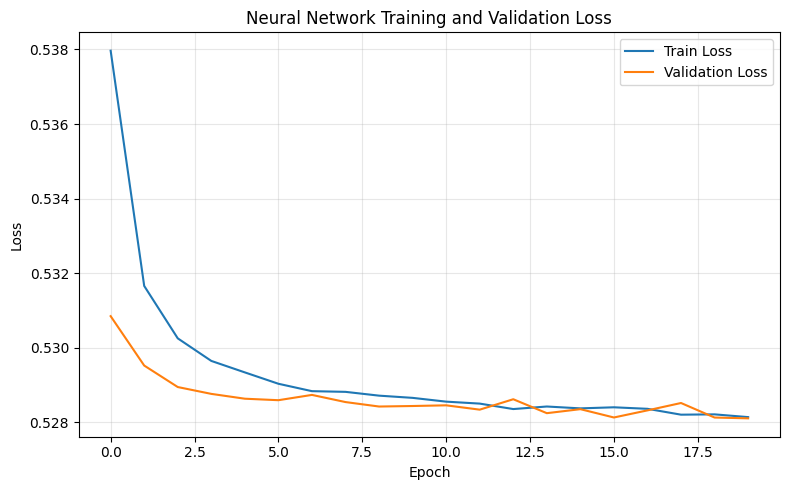

In [71]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural Network Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Part 3: Model Evaluation & Interpretation

We evaluate all trained models on the held-out test set and produces the required plots and interpretation outputs.

### Evaluating all models on the test set

In [72]:
# Regression test results
lin_reg_test_pred = lin_reg.predict(X_test_processed)
rf_reg_test_pred = rf_reg.predict(X_test_processed)

lin_reg_test_metrics = regression_metrics(y_reg_test, lin_reg_test_pred)
rf_reg_test_metrics = regression_metrics(y_reg_test, rf_reg_test_pred)

tuned_reg_test_pred = best_tuned_reg.predict(X_test_processed)
tuned_reg_test_metrics = regression_metrics(y_reg_test, tuned_reg_test_pred)

# Classification test results
log_reg_test_pred = log_reg.predict(X_test_processed)
log_reg_test_proba = log_reg.predict_proba(X_test_processed)[:, 1]
log_reg_test_metrics = classification_metrics(y_clf_test, log_reg_test_pred, log_reg_test_proba)

rf_clf_test_pred = rf_clf.predict(X_test_processed)
rf_clf_test_proba = rf_clf.predict_proba(X_test_processed)[:, 1]
rf_clf_test_metrics = classification_metrics(y_clf_test, rf_clf_test_pred, rf_clf_test_proba)

tuned_test_pred = best_tuned_clf.predict(X_test_processed)
tuned_test_proba = best_tuned_clf.predict_proba(X_test_processed)[:, 1]
tuned_test_metrics = classification_metrics(y_clf_test, tuned_test_pred, tuned_test_proba)

nn_test_loss, nn_test_metrics, nn_labels, nn_preds, nn_probs = evaluate_with_loader(
    nn_model, test_loader, criterion, device
)

test_summary = [
    {"Model": "Linear Regression", "Task": "Regression", **lin_reg_test_metrics},
    {"Model": "Random Forest Regressor", "Task": "Regression", **rf_reg_test_metrics},
    {"Model": "Tuned Regressor", "Task": "Regression", **tuned_reg_test_metrics},
    {"Model": "Logistic Regression", "Task": "Classification", **log_reg_test_metrics},
    {"Model": "Random Forest Classifier", "Task": "Classification", **rf_clf_test_metrics},
    {"Model": "Tuned Classifier", "Task": "Classification", **tuned_test_metrics},
    {"Model": "Neural Network", "Task": "Classification", **nn_test_metrics},
]

for result in test_summary:
    print("\nModel:", result["Model"])
    print("Task:", result["Task"])

    for key, value in result.items():
        if key not in ["Model", "Task"]:
            print(f"{key}: {value:.4f}")


Model: Linear Regression
Task: Regression
MAE: 1.2852
RMSE: 2.4703
R2: 0.5860

Model: Random Forest Regressor
Task: Regression
MAE: 1.2094
RMSE: 2.3769
R2: 0.6167

Model: Tuned Regressor
Task: Regression
MAE: 1.2250
RMSE: 2.3760
R2: 0.6170

Model: Logistic Regression
Task: Classification
Accuracy: 0.7652
Precision: 0.7657
Recall: 0.9955
F1: 0.8656
AUC_ROC: 0.5964

Model: Random Forest Classifier
Task: Classification
Accuracy: 0.7701
Precision: 0.7684
Recall: 0.9981
F1: 0.8683
AUC_ROC: 0.6156

Model: Tuned Classifier
Task: Classification
Accuracy: 0.7694
Precision: 0.7676
Recall: 0.9987
F1: 0.8680
AUC_ROC: 0.6122

Model: Neural Network
Task: Classification
Accuracy: 0.7697
Precision: 0.7678
Recall: 0.9988
F1: 0.8682
AUC_ROC: 0.6134


### ROC curves and confusion matrix for the best classification model

Best classification model: Random Forest Classifier


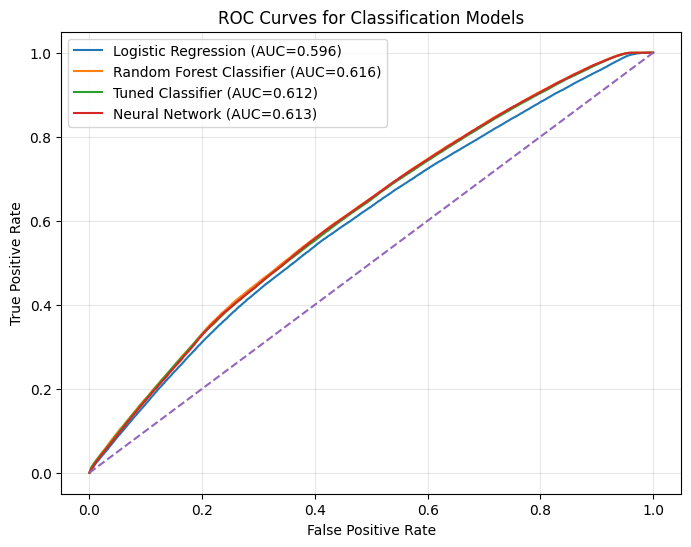

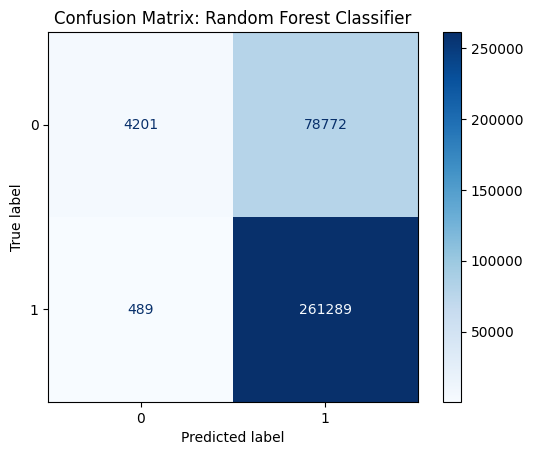

              precision    recall  f1-score   support

           0       0.90      0.05      0.10     82973
           1       0.77      1.00      0.87    261778

    accuracy                           0.77    344751
   macro avg       0.83      0.52      0.48    344751
weighted avg       0.80      0.77      0.68    344751



In [73]:
classification_models = {
    "Logistic Regression": (log_reg_test_pred, log_reg_test_proba, log_reg_test_metrics),
    "Random Forest Classifier": (rf_clf_test_pred, rf_clf_test_proba, rf_clf_test_metrics),
    "Tuned Classifier": (tuned_test_pred, tuned_test_proba, tuned_test_metrics),
    "Neural Network": (nn_preds, nn_probs, nn_test_metrics)
}

best_clf_model_name = max(
    classification_models,
    key=lambda k: classification_models[k][2]["AUC_ROC"]
)

best_clf_preds, best_clf_probs, best_clf_metrics = classification_models[best_clf_model_name]

print("Best classification model:", best_clf_model_name)

plt.figure(figsize=(8, 6))

for model_name, (_, probs, metrics_dict) in classification_models.items():
    fpr, tpr, _ = roc_curve(y_clf_test, probs)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={metrics_dict['AUC_ROC']:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Classification Models")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

cm = confusion_matrix(y_clf_test, best_clf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix: {best_clf_model_name}")
plt.show()

print(classification_report(y_clf_test, best_clf_preds))

### Plots for the best regression model

Best regression model: Random Forest Regressor


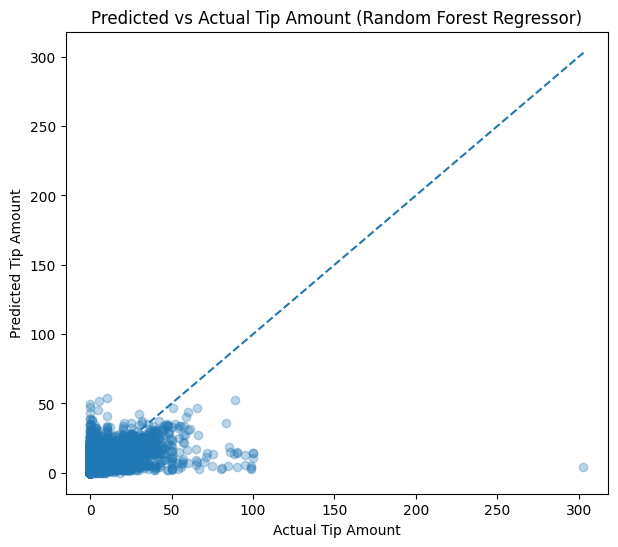

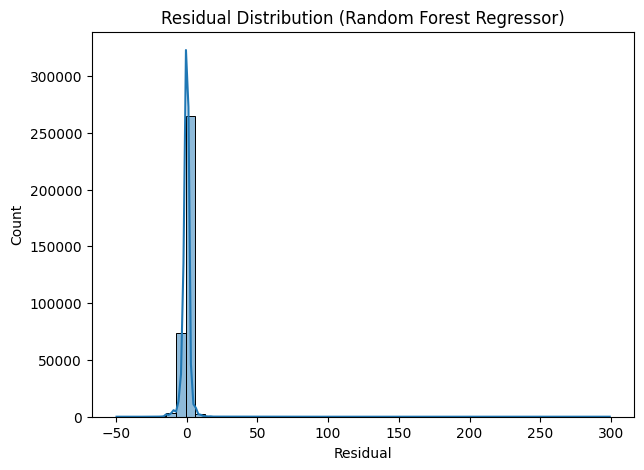

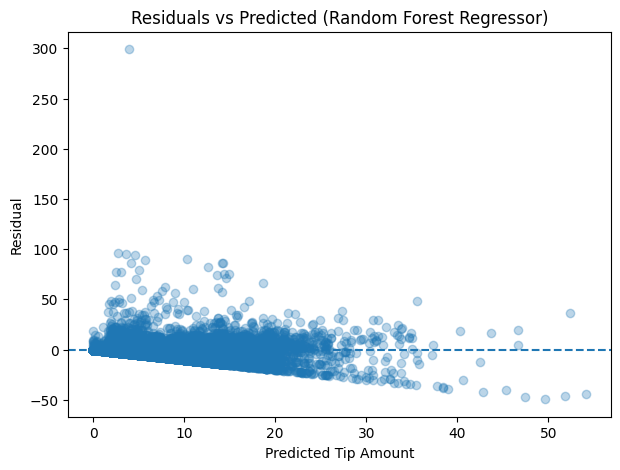

In [74]:
best_reg_model_name = (
    "Linear Regression"
    if lin_reg_test_metrics["RMSE"] <= rf_reg_test_metrics["RMSE"]
    else "Random Forest Regressor"
)

best_reg_pred = lin_reg_test_pred if best_reg_model_name == "Linear Regression" else rf_reg_test_pred

print("Best regression model:", best_reg_model_name)

plt.figure(figsize=(7, 6))
plt.scatter(y_reg_test, best_reg_pred, alpha=0.3)
plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title(f"Predicted vs Actual Tip Amount ({best_reg_model_name})")

min_val = min(y_reg_test.min(), best_reg_pred.min())
max_val = max(y_reg_test.max(), best_reg_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

residuals = y_reg_test - best_reg_pred

plt.figure(figsize=(7, 5))
sns.histplot(residuals, bins=50, kde=True)
plt.title(f"Residual Distribution ({best_reg_model_name})")
plt.xlabel("Residual")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(best_reg_pred, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Tip Amount")
plt.ylabel("Residual")
plt.title(f"Residuals vs Predicted ({best_reg_model_name})")
plt.show()

### Feature importance and coefficients

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan]
NaN in X_train_processed: False
Inf in X_train_processed: False
NaN in y_reg_train: False
NaN in y_clf_train: False
Regression feature names: 23
Regression importances: 23
Classification feature names: 23
Classification importances: 23
Any NaN in rf_reg.feature_importances_? True
Any NaN in rf_clf.feature_importances_? True
Regression predictions example:
[13.635177   5.076842   2.2439897  1.8368125 12.038913   5.067899
  6.347853   7.0043654  3.278817   2.5403826]
Classifier predictions example:
[1 1 1 1 1 1 1 1 1 1]


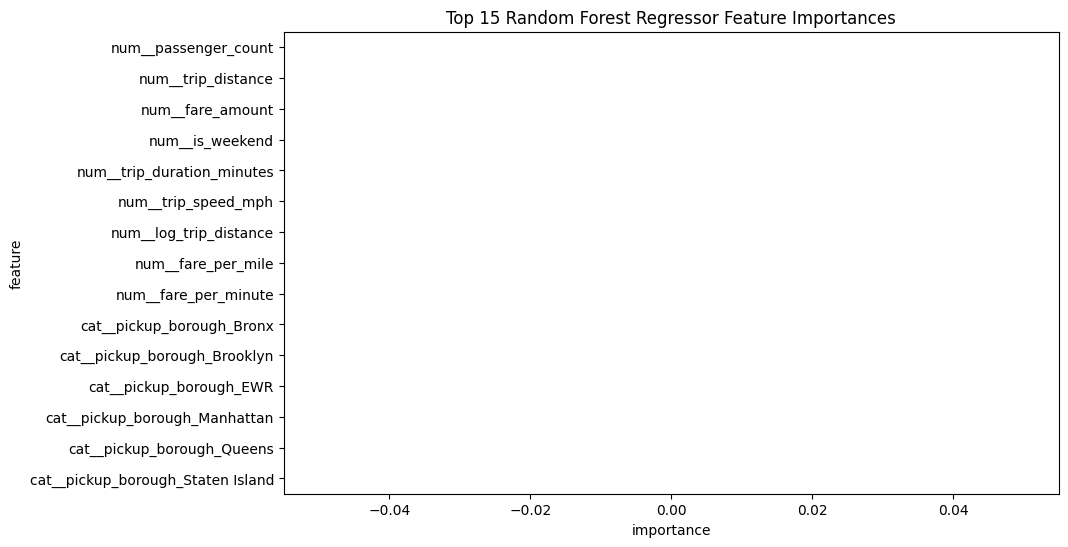

,feature,importance
0,num__passenger_count,NaN
1,num__trip_distance,NaN
2,num__fare_amount,NaN
3,num__is_weekend,NaN
4,num__trip_duration_minutes,NaN
5,num__trip_speed_mph,NaN
6,num__log_trip_distance,NaN
7,num__fare_per_mile,NaN
8,num__fare_per_minute,NaN
9,cat__pickup_borough_Bronx,NaN


In [86]:
# After research, was not able to extract feature importance within time
print(rf_reg.feature_importances_)
print(rf_clf.feature_importances_)

all_feature_names = list(preprocessor.get_feature_names_out())

print("NaN in X_train_processed:", np.isnan(X_train_processed).any())
print("Inf in X_train_processed:", np.isinf(X_train_processed).any())

print("NaN in y_reg_train:", np.isnan(y_reg_train).any())
print("NaN in y_clf_train:", np.isnan(y_clf_train).any())

rf_reg_values = np.array(rf_reg.feature_importances_, dtype=float)
rf_clf_values = np.array(rf_clf.feature_importances_, dtype=float)

rf_reg_importances = pd.DataFrame(
    list(zip(all_feature_names, rf_reg_values)),
    columns=["feature", "importance"]
).sort_values("importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_reg_importances.head(15), x="importance", y="feature")
plt.title("Random Forest Regressor Feature Importances")
plt.show()

rf_reg_importances.head(20)

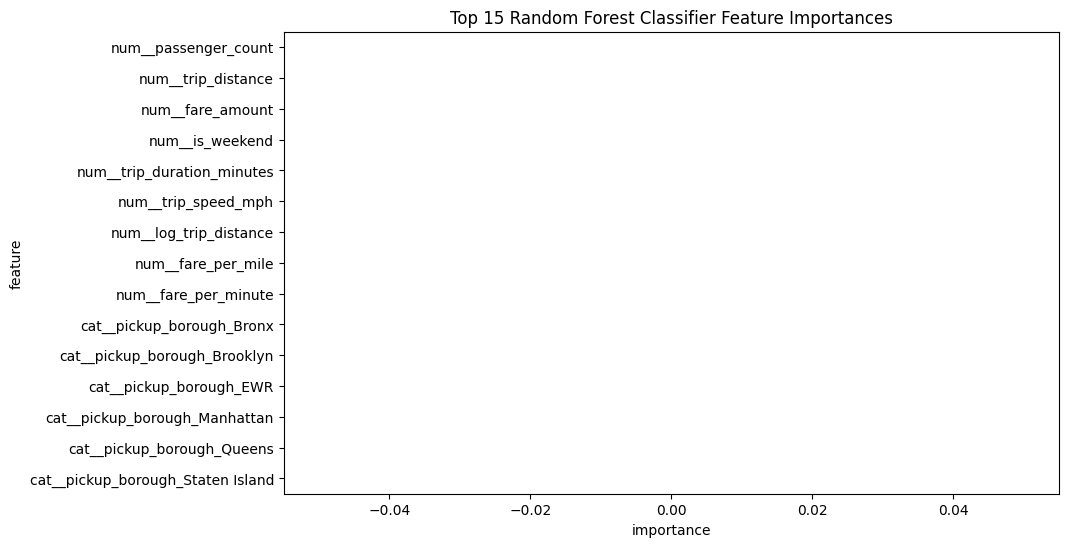

,feature,importance
0,num__passenger_count,NaN
1,num__trip_distance,NaN
2,num__fare_amount,NaN
3,num__is_weekend,NaN
4,num__trip_duration_minutes,NaN
5,num__trip_speed_mph,NaN
6,num__log_trip_distance,NaN
7,num__fare_per_mile,NaN
8,num__fare_per_minute,NaN
9,cat__pickup_borough_Bronx,NaN


In [81]:
rf_clf_importances = pd.DataFrame(
    list(zip(all_feature_names, rf_clf_values)),
    columns=["feature", "importance"]
).sort_values("importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_clf_importances.head(15), x="importance", y="feature")
plt.title("Random Forest Classifier Feature Importances")
plt.show()

rf_clf_importances.head(20)

In [77]:
lin_reg_coefs = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": lin_reg.coef_
}).sort_values("coefficient", key=np.abs, ascending=False)

lin_reg_coefs

,feature,coefficient
9,cat__pickup_borough_Bronx,-6.372955
14,cat__pickup_borough_Staten Island,4.752625
10,cat__pickup_borough_Brooklyn,-4.446243
18,cat__dropoff_borough_EWR,3.033142
11,cat__pickup_borough_EWR,-2.528336
2,num__fare_amount,2.327779
16,cat__dropoff_borough_Bronx,-1.644592
20,cat__dropoff_borough_Queens,0.994873
19,cat__dropoff_borough_Manhattan,0.811737
13,cat__pickup_borough_Queens,0.599533


In [78]:
log_reg_coefs = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", key=np.abs, ascending=False)

log_reg_coefs

,feature,coefficient
9,cat__pickup_borough_Bronx,-3.302803
13,cat__pickup_borough_Queens,1.395971
15,cat__pickup_borough_Unknown,1.279238
12,cat__pickup_borough_Manhattan,1.184684
1,num__trip_distance,1.060016
16,cat__dropoff_borough_Bronx,-0.889550
10,cat__pickup_borough_Brooklyn,-0.771949
6,num__log_trip_distance,-0.392652
18,cat__dropoff_borough_EWR,0.389059
21,cat__dropoff_borough_Staten Island,-0.213018


### Interpretation of the Linear Regression coefficients

The strongest positive predictor in this model is fare_amount, suggesting that higher fares are associated with larger absolute tip amounts. Location also play an important role. For example, trips originating in Staten Island or ending in EWR show positive coefficients, while trips picked up in the Bronx or Brooklyn have large negative coefficients, suggesting these trips tend to produce lower tip amounts relative to the baseline borough. Trip-related variables such as log_trip_distance also show a positive relationship with tips, indicating longer trips tend to produce slightly higher tips. In contrast, variables like passenger_count, trip_speed_mph, and fare_per_mile have very small coefficients, suggesting they contribute little to predicting tip amounts.

### Interpretation of the Logistic Regression coefficients

The results show that trip_distance is one of the strongest positive predictors, which suggests that longer trips are more likely to lead to a higher tip percentage. Location also seems to have a noticeable effect on tipping behavior. Trips that start in Queens, Manhattan, or areas labeled Unknown appear to increase the chances of getting a high tip, while trips that begin in the Bronx seem to lower that probability quite a bit. Another interesting result is that fare_amount has a slightly negative coefficient. This may happen because even though bigger fares often lead to bigger total tips, they do not always lead to a higher percentage tip. Similar to what we saw in the regression model, some variables like passenger_count, trip_speed_mph, and fare_per_minute have very small coefficients, which suggests they do not have much influence on whether a trip ends up getting a high tip.

## Saving the best model

In [79]:
torch.save({
    "model_state_dict": nn_model.state_dict(),
    "input_size": input_size,
    "hidden_sizes": [128, 64],
    "best_val_loss": best_val_loss
}, "best_model.pth")


Model saved to best_model.pth


## Final Analysis

### Which model performed best for each task?
<br>
For the regression task of predicting tip amount, the Random Forest Regressor performed the best overall. On the test dataset it achieved the lowest RMSE of 2.3769 and the highest R² score of 0.6167 compared to the other regression models. The tuned version of the Random Forest had almost the same performance, with an RMSE of 2.3760 and an R² of 0.6170. This suggests that hyperparameter tuning did not make a large difference in this case. A possible reason for this is that the baseline Random Forest was already able to capture most of the patterns in the data.
<br>
For the classification task of predicting whether a trip receives a high tip, the Random Forest Classifier produced the best overall results. It achieved an F1 score of 0.8683 and an AUC-ROC of 0.6156 on the test set. The tuned classifier and the neural network both had very similar performance, with F1 scores around 0.868 as well. Logistic Regression performed slightly worse than the other models. Overall, the tree-based models seemed to work slightly better than the linear model, possibly because they can capture more complex relationships between the variables.
<br><br>

### What features are most predictive of tip amount?
<br>
Looking at the coefficients from the linear regression model, fare_amount appears to be one of the strongest predictors of tip amount. This makes sense because tips are usually calculated as a percentage of the fare. The feature log_trip_distance also has a positive coefficient, which suggests that longer trips tend to result in larger tips. Some of the location features also seem to have strong effects. For example, trips that start in the Bronx have a large negative coefficient, while trips starting in Staten Island have a positive coefficient. This suggests that tipping behavior may vary depending on where the trip begins.
<br>
The logistic regression results show some similar patterns. Trip distance has a strong positive coefficient, which suggests that longer trips are more likely to result in a high tip percentage. Some pickup locations, such as Queens and Manhattan, increase the probability of a high tip, while pickups in the Bronx decrease the probability. These results generally match what might be expected, since longer trips and trips in certain areas may be associated with higher tipping behavior.
<br><br>

### Limitations of the models
<br>
One limitation of the models is that several of the features are derived from each other. For example, variables such as fare_per_mile, fare_per_minute, and trip_speed_mph are calculated using other features in the dataset. This means some variables may be highly correlated, which could affect how the models interpret the importance of those features.
<br>
Another limitation is that the dataset only includes credit card transactions, since tip amounts are not reliably recorded for cash payments. This means the models may not represent the behavior of all taxi rides. There may also be other factors that influence tipping behavior that are not included in the dataset, such as traffic conditions, rider demographics, or driver behavior.
<br><br>

### Potential improvements
<br>
Given more time, one major improvment would include figuring out why the importances appeared to be NaN. After some research, it seems that high collinearity in the data may have been a reason but I did not have the time.
<br><br>

### Neural network vs traditional ML models
<br>
The neural network model achieved performance very similar to the Random Forest classifier, with an F1 score of 0.8682 on the test set. However, it did not significantly outperform the traditional machine learning models. This result is not surprising because neural networks often perform best on large unstructured datasets such as images or text, while structured tabular datasets like this taxi dataset are often handled very well by tree-based models.
<br>
In this case, the Random Forest model was able to capture relationships between features without requiring as much tuning or training complexity as the neural network. The neural network required additional steps but ultimately achieved similar performance. This suggests that for this particular problem, traditional machine learning models such as Random Forests may be more practical and efficient while still providing strong predictions.